In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

from scripts.analysis import calculate_metrics_df

In [2]:
fund_df = pd.read_csv('data/fund_navs.csv')
fund_df.set_index('date', inplace=True)

fund_df

,120403,120381,148073,118989,119775,147445,118668,140228,129649,145678,...,120670,118814,141588,118569,119788,115132,119781,119132,149775,149760
date,,,,,,,,,,,,,,,,,,,,,
2022-02-11,98.86,172.18,27.83,98.162,78.594,21.414,2160.3426,54.993,30.50,27.56,...,38.2218,49.2521,14.1726,85.0425,15.4975,19.4375,20.7904,15.9089,10.1411,10.1177
2022-02-18,96.81,167.86,27.01,95.962,77.679,21.049,2113.1932,53.577,29.77,26.83,...,38.3254,49.3163,14.1876,85.1572,15.8451,19.8919,21.1214,16.2909,10.3756,10.3444
2022-02-25,93.84,162.92,26.36,93.215,75.638,20.274,2065.2842,52.545,28.94,26.17,...,38.3340,49.3455,14.1892,85.1980,15.9925,20.1231,21.2871,16.4963,10.5301,10.4836
2022-03-04,91.67,159.54,25.83,91.673,74.236,20.100,2016.5119,51.524,28.94,26.01,...,38.2722,49.3192,14.1822,85.1571,16.3622,20.5959,21.7396,16.8199,10.9621,10.9426
2022-03-11,94.08,164.13,26.36,94.305,76.265,20.530,2048.6223,52.904,29.53,26.72,...,38.2622,49.3431,14.1846,85.1472,16.5093,20.8759,21.8689,17.0668,11.2350,11.2692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-28,245.07,399.30,58.69,237.066,173.634,45.039,5045.8416,131.382,67.95,66.14,...,53.7293,67.1539,19.3408,115.9812,48.3391,60.6083,63.9426,49.3748,36.8949,36.7146
2026-09-04,242.94,391.79,57.86,234.584,171.800,44.546,4987.3718,129.994,67.76,66.18,...,53.8203,67.3374,19.3902,116.3378,46.9757,58.9694,62.1366,47.9712,35.6601,35.4961
2026-09-11,241.27,384.71,57.43,230.603,169.773,43.968,4943.7593,128.520,68.18,66.35,...,53.7778,67.2849,19.3771,116.3843,46.2005,57.9200,61.0345,47.2103,34.7266,34.5296


In [3]:
returns_matrix = fund_df.pct_change().ffill().dropna()
returns_matrix

,120403,120381,148073,118989,119775,147445,118668,140228,129649,145678,...,120670,118814,141588,118569,119788,115132,119781,119132,149775,149760
date,,,,,,,,,,,,,,,,,,,,,
2022-02-18,-0.020736,-0.025090,-0.029465,-0.022412,-0.011642,-0.017045,-0.021825,-0.025749,-0.023934,-0.026488,...,0.002710,0.001303,0.001058,0.001349,0.022429,0.023377,0.015921,0.024012,0.023124,0.022406
2022-02-25,-0.030679,-0.029429,-0.024065,-0.028626,-0.026275,-0.036819,-0.022671,-0.019262,-0.027880,-0.024599,...,0.000224,0.000592,0.000113,0.000479,0.009303,0.011623,0.007845,0.012608,0.014891,0.013457
2022-03-04,-0.023124,-0.020746,-0.020106,-0.016542,-0.018536,-0.008582,-0.023615,-0.019431,0.000000,-0.006114,...,-0.001612,-0.000533,-0.000493,-0.000480,0.023117,0.023495,0.021257,0.019617,0.041025,0.043783
2022-03-11,0.026290,0.028770,0.020519,0.028711,0.027332,0.021393,0.015924,0.026784,0.020387,0.027297,...,-0.000261,0.000485,0.000169,-0.000116,0.008990,0.013595,0.005948,0.014679,0.024895,0.029847
2022-03-18,0.033801,0.022787,0.022762,0.021674,0.029476,0.028251,0.028315,0.028429,0.014900,0.017590,...,0.002143,0.001419,0.002073,0.001825,-0.016088,-0.022452,-0.013732,-0.022183,-0.023988,-0.027695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-28,0.004921,0.013066,0.002049,0.002020,0.004257,0.010002,-0.001867,0.003935,0.006518,0.005320,...,0.000559,0.000431,0.000191,0.000638,-0.004611,-0.003649,-0.004981,-0.002473,-0.009674,-0.010783
2026-09-04,-0.008691,-0.018808,-0.014142,-0.010470,-0.010562,-0.010946,-0.011588,-0.010565,-0.002796,0.000605,...,0.001694,0.002733,0.002554,0.003075,-0.028205,-0.027041,-0.028244,-0.028427,-0.033468,-0.033188
2026-09-11,-0.006874,-0.018071,-0.007432,-0.016970,-0.011799,-0.012975,-0.008745,-0.011339,0.006198,0.002569,...,-0.000790,-0.000780,-0.000676,0.000400,-0.016502,-0.017796,-0.017737,-0.015862,-0.026178,-0.027228


In [4]:
print(returns_matrix.isna().sum().sum())
print(returns_matrix.dtypes)
print(returns_matrix.min().min())
print(returns_matrix.max().max())

0
120403    float64
120381    float64
148073    float64
118989    float64
119775    float64
147445    float64
118668    float64
140228    float64
129649    float64
145678    float64
147919    float64
119212    float64
145137    float64
149019    float64
119589    float64
119556    float64
120828    float64
119539    float64
119082    float64
119382    float64
130543    float64
118780    float64
120670    float64
118814    float64
141588    float64
118569    float64
119788    float64
115132    float64
119781    float64
119132    float64
149775    float64
149760    float64
dtype: object
-0.29168174492530086
0.1707973788360475


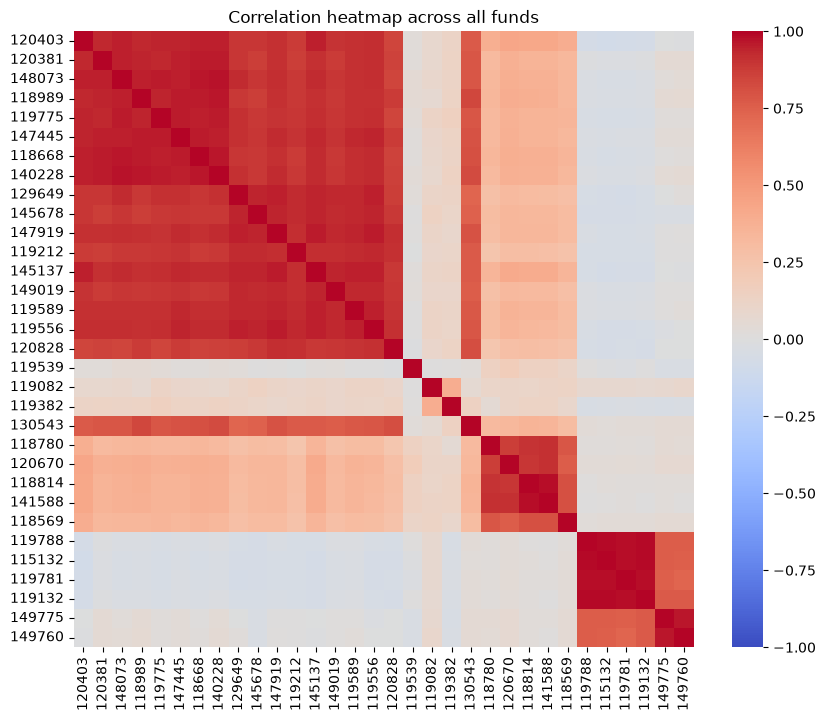

In [5]:
corr_matrix = returns_matrix.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across all funds")
plt.show()

In [6]:
fund_types = json.load(open('data/fund_names.json', 'r'))

In [7]:
nifty_50_df = pd.read_csv('data/nifty_50.csv')
nifty_50_df

,Date,Nifty_50
0,2022-01-07,17812.699219
1,2022-01-14,18255.750000
2,2022-01-21,17617.150391
3,2022-01-28,17101.949219
4,2022-02-04,17516.300781
...,...,...
242,2026-08-28,24175.650391
243,2026-09-04,23897.699219
244,2026-09-11,23398.099609
245,2026-09-18,23346.400391


In [8]:
nifty_50_df = nifty_50_df[nifty_50_df['Date'] >= '2022-02-11']
nifty_50_df = nifty_50_df.set_index('Date')
nifty_50_returns = nifty_50_df.pct_change().dropna()

nifty_50_returns

,Nifty_50
Date,
2022-02-18,-0.005666
2022-02-25,-0.035766
2022-03-04,-0.024795
2022-03-11,0.023705
2022-03-18,0.039482
...,...
2026-08-28,-0.003148
2026-09-04,-0.011497
2026-09-11,-0.020906


In [9]:
midcap_funds = returns_matrix[[code for code in fund_types['mid_cap'].keys() if code in returns_matrix.columns]]
midcap_funds = midcap_funds.rename(columns=fund_types['mid_cap'])
midcap_funds

,Invesco India Mid Cap Fund - Direct Plan - Growth Option,ICICI Prudential Mid Cap Fund - Direct Plan - Growth,Union Midcap Fund - Direct Plan - Growth Option,HDFC Mid Cap Fund - Growth Option - Direct Plan,Kotak Mid Cap Fund - Direct Plan - Growth,Mirae Asset Midcap Fund - Direct Plan - Growth,Nippon India Growth Mid Cap Fund - Direct Plan Growth Plan - Growth Option,Edelweiss Mid Cap Fund - Direct Plan - Growth Option
date,,,,,,,,
2022-02-18,-0.020736,-0.025090,-0.029465,-0.022412,-0.011642,-0.017045,-0.021825,-0.025749
2022-02-25,-0.030679,-0.029429,-0.024065,-0.028626,-0.026275,-0.036819,-0.022671,-0.019262
2022-03-04,-0.023124,-0.020746,-0.020106,-0.016542,-0.018536,-0.008582,-0.023615,-0.019431
2022-03-11,0.026290,0.028770,0.020519,0.028711,0.027332,0.021393,0.015924,0.026784
2022-03-18,0.033801,0.022787,0.022762,0.021674,0.029476,0.028251,0.028315,0.028429
...,...,...,...,...,...,...,...,...
2026-08-28,0.004921,0.013066,0.002049,0.002020,0.004257,0.010002,-0.001867,0.003935
2026-09-04,-0.008691,-0.018808,-0.014142,-0.010470,-0.010562,-0.010946,-0.011588,-0.010565
2026-09-11,-0.006874,-0.018071,-0.007432,-0.016970,-0.011799,-0.012975,-0.008745,-0.011339


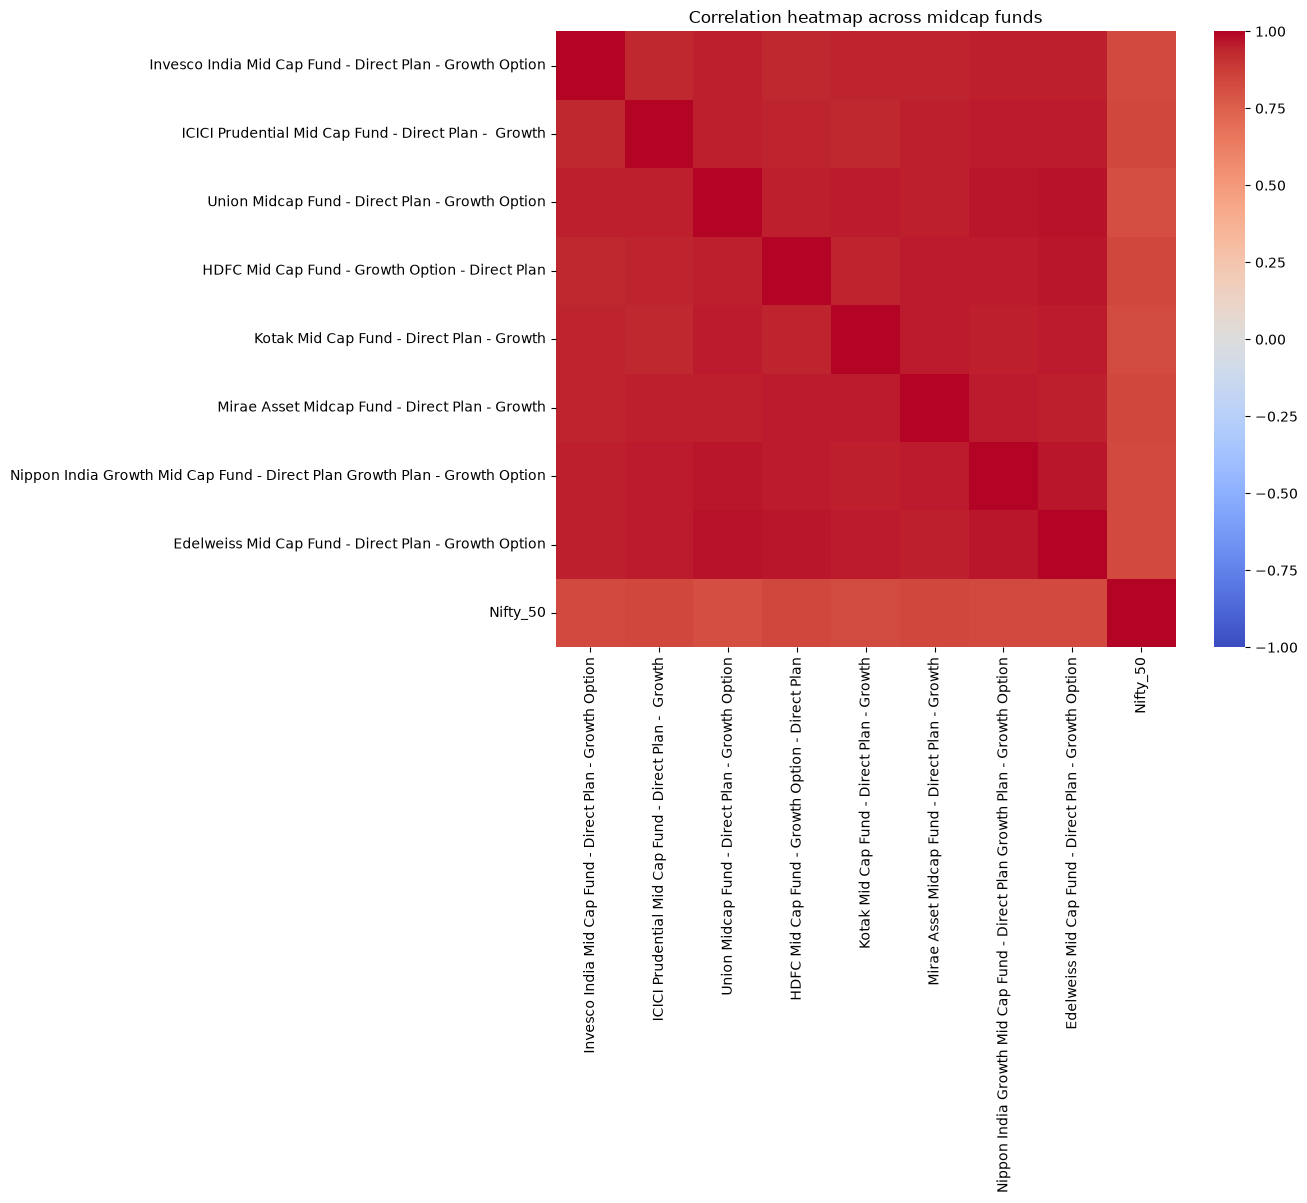

In [10]:
midcap_with_benchmarks = pd.concat([midcap_funds, nifty_50_returns['Nifty_50']], axis=1).dropna()
midcap_corr_matrix = midcap_with_benchmarks.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    midcap_corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across midcap funds")
plt.show()

In [11]:
smallcap_funds = returns_matrix[[code for code in fund_types['small_cap'].keys() if code in returns_matrix.columns]]
smallcap_funds = smallcap_funds.rename(columns=fund_types['small_cap'])
smallcap_funds

,Union Small Cap Fund - Direct Plan - Growth Option,BANK OF INDIA Small Cap Fund Direct Plan Growth,ITI Small Cap Fund - Direct Plan - Growth Option,DSP Small Cap Fund - Direct Plan - Growth,Invesco India Small Cap Fund - Direct Plan - Growth,PGIM India Small Cap Fund - Direct Plan- Growth Option,Sundaram Small Cap Fund Direct Plan - Growth,Aditya Birla Sun Life Small Cap Fund - Growth - Direct Plan,quant Small Cap Fund - Growth Option - Direct Plan
date,,,,,,,,,
2022-02-18,-0.023934,-0.026488,-0.028421,-0.037154,-0.033062,-0.028933,-0.028030,-0.035202,-0.052209
2022-02-25,-0.027880,-0.024599,-0.050925,-0.034876,-0.035129,-0.040968,-0.028963,-0.040842,-0.056716
2022-03-04,0.000000,-0.006114,-0.005511,0.003764,-0.006796,0.003883,-0.013675,-0.008131,0.006423
2022-03-11,0.020387,0.027297,0.000066,0.047750,0.027859,0.042553,0.029987,0.008279,0.036526
2022-03-18,0.014900,0.017590,0.031597,0.008328,0.022825,0.016698,0.025732,0.025909,0.014650
...,...,...,...,...,...,...,...,...,...
2026-08-28,0.006518,0.005320,0.006810,0.004012,0.007527,-0.001965,-0.005674,0.009502,0.014717
2026-09-04,-0.002796,0.000605,-0.000850,-0.000971,-0.002187,0.002953,-0.000123,-0.000711,0.002693
2026-09-11,0.006198,0.002569,0.005191,-0.002985,-0.005844,-0.001963,0.003990,0.000063,-0.001509


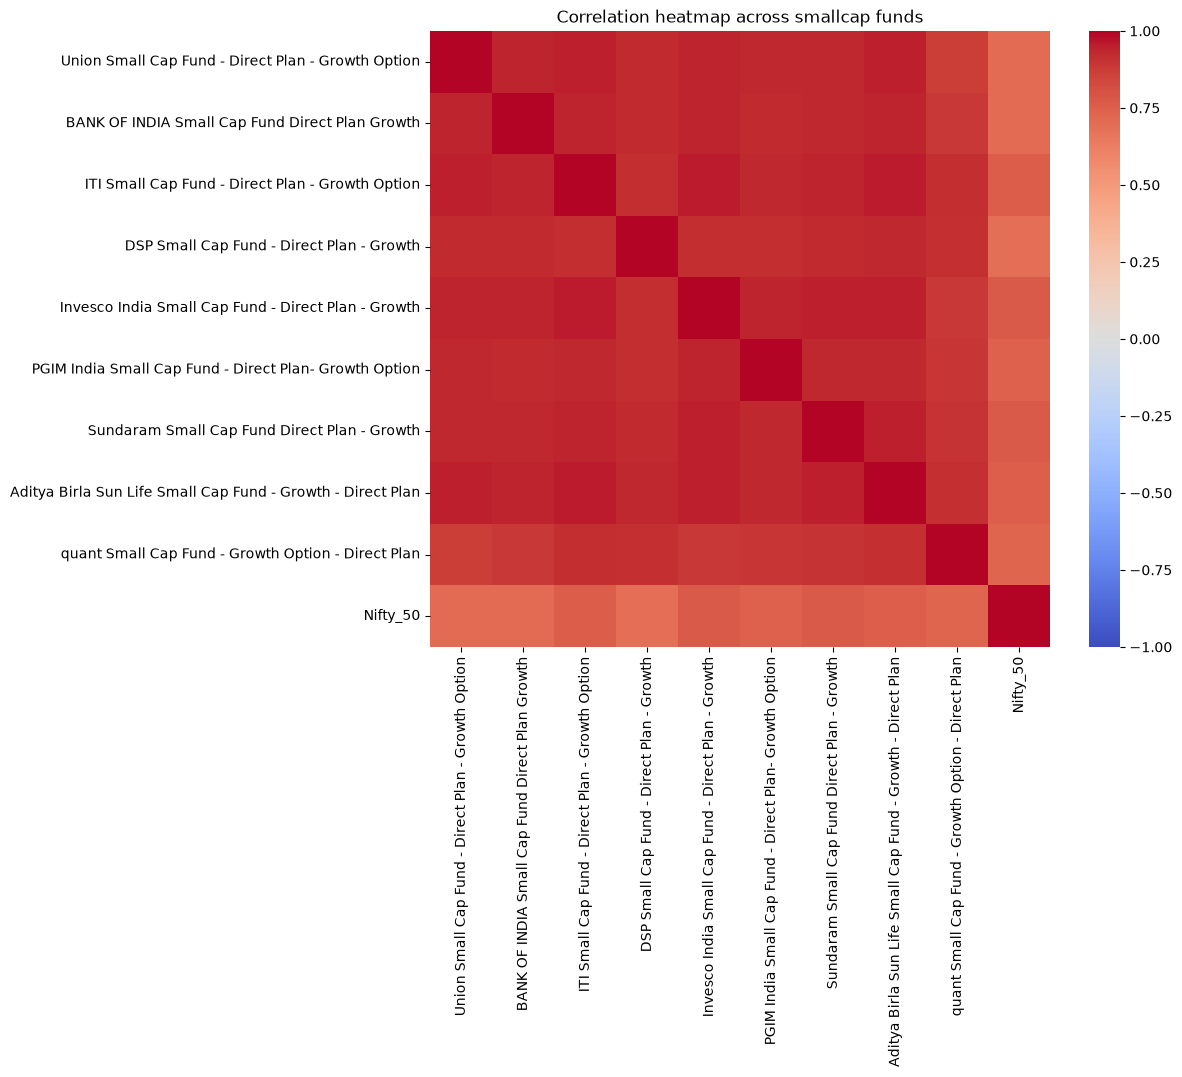

In [12]:
smallcap_with_benchmarks = pd.concat([smallcap_funds, nifty_50_returns['Nifty_50']], axis=1).dropna()
smallcap_corr_matrix = smallcap_with_benchmarks.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    smallcap_corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across smallcap funds")
plt.show()

In [13]:
debt_funds = returns_matrix[[code for code in fund_types['debt'].keys() if code in returns_matrix.columns]]
debt_funds = debt_funds.rename(columns=fund_types['debt'])
debt_funds

,Aditya Birla Sun Life Medium Term Fund - Growth - Direct Plan,DSP Credit Risk Fund - Direct Plan - Growth,BANK OF INDIA Short Term Income Fund-Direct Plan- Growth,HDFC Income Plus Arbitrage Active FOF - Growth Option - Direct Plan,Nippon India Credit Risk Fund - Direct Plan - Growth Plan,ICICI Prudential Medium Term Fund - Direct Plan - Growth,Nippon India Corporate Bond Fund - Direct Plan Growth Plan - Growth Option,Axis Corporate Bond Fund - Direct Plan Growth,Franklin India Corporate Debt Fund - Direct - GROWTH
date,,,,,,,,,
2022-02-18,0.039282,0.000910,0.000925,-0.008582,0.001697,0.002710,0.001303,0.001058,0.001349
2022-02-25,-0.000801,0.000185,-0.000744,-0.016042,0.000239,0.000224,0.000592,0.000113,0.000479
2022-03-04,-0.000999,-0.000696,-0.000122,-0.006298,-0.000662,-0.001612,-0.000533,-0.000493,-0.000480
2022-03-11,-0.000949,-0.000189,0.000271,0.012985,0.000185,-0.000261,0.000485,0.000169,-0.000116
2022-03-18,0.002202,0.001911,0.001659,0.013313,0.002344,0.002143,0.001419,0.002073,0.001825
...,...,...,...,...,...,...,...,...,...
2026-08-28,0.000194,0.000597,0.000648,0.000184,0.001236,0.000559,0.000431,0.000191,0.000638
2026-09-04,0.001904,0.002499,0.002326,0.000965,0.002969,0.001694,0.002733,0.002554,0.003075
2026-09-11,-0.000583,0.000475,-0.000138,0.000428,0.000309,-0.000790,-0.000780,-0.000676,0.000400


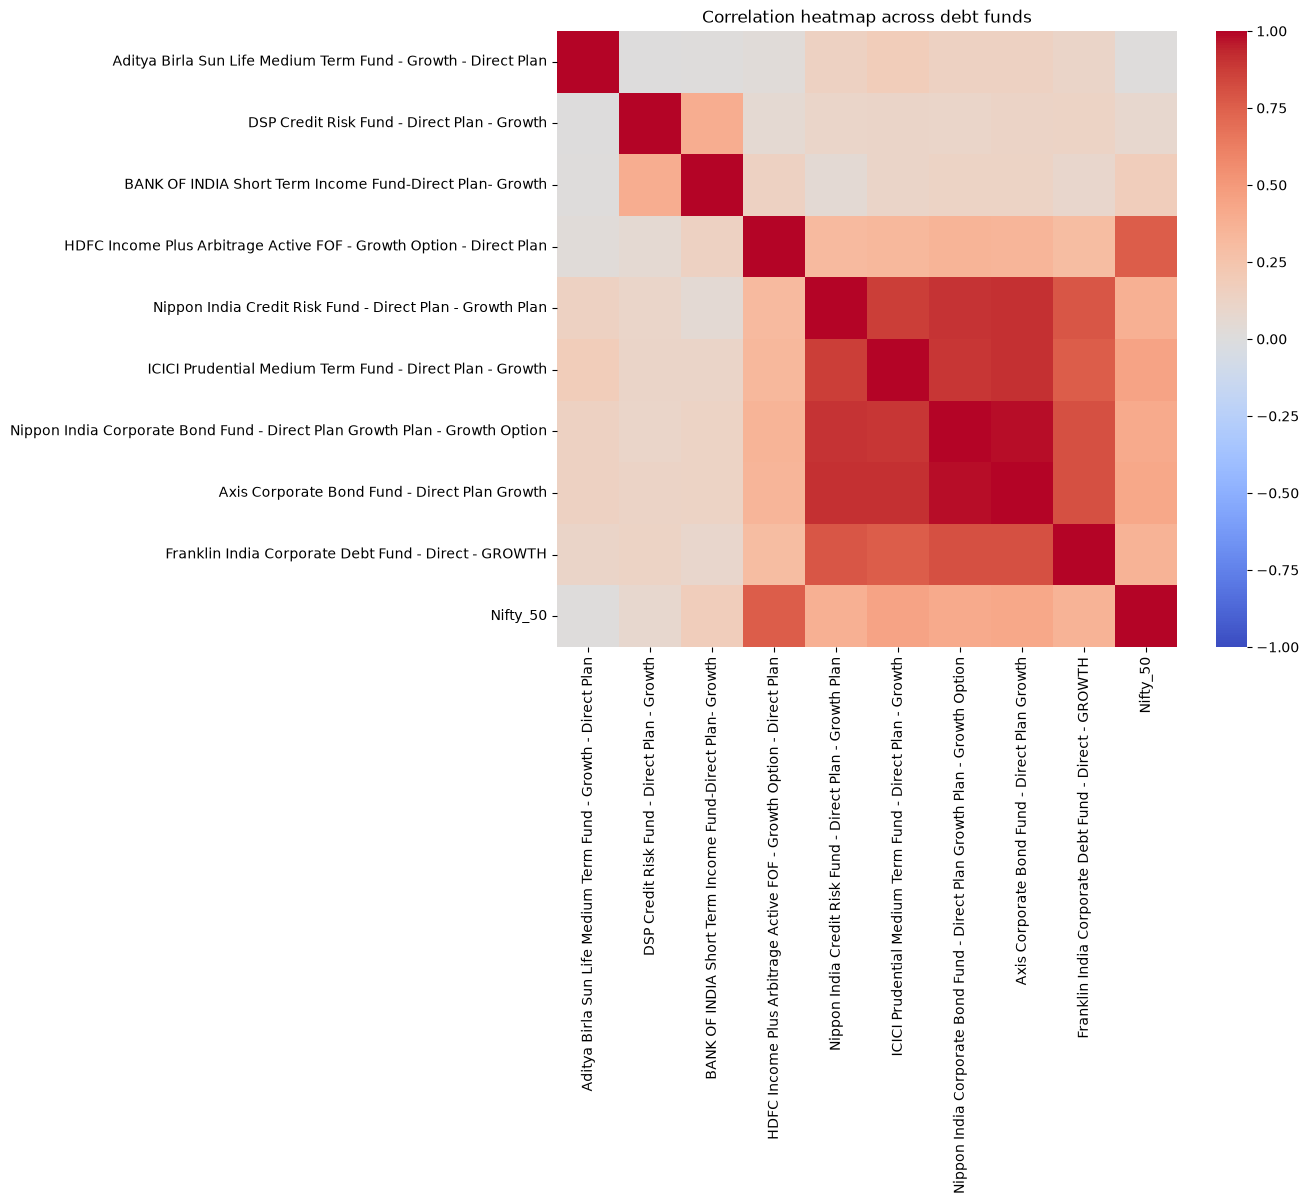

In [14]:
debt_with_benchmarks = pd.concat([debt_funds, nifty_50_returns['Nifty_50']], axis=1).dropna()
debt_corr_matrix = debt_with_benchmarks.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    debt_corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across debt funds")
plt.show()

In [15]:
gold_funds = returns_matrix[[code for code in fund_types['gold'].keys() if code in returns_matrix.columns]]
gold_funds = gold_funds.rename(columns=fund_types['gold'])
gold_funds

,SBI GOLD FUND- DIRECT PLAN - GROWTH,Quantum Gold ETF FOF - Direct Plan Growth Option,Kotak Gold Fund Growth - Direct,HDFC Gold ETF Fund of Fund - Direct Plan
date,,,,
2022-02-18,0.022429,0.023377,0.015921,0.024012
2022-02-25,0.009303,0.011623,0.007845,0.012608
2022-03-04,0.023117,0.023495,0.021257,0.019617
2022-03-11,0.008990,0.013595,0.005948,0.014679
2022-03-18,-0.016088,-0.022452,-0.013732,-0.022183
...,...,...,...,...
2026-08-28,-0.004611,-0.003649,-0.004981,-0.002473
2026-09-04,-0.028205,-0.027041,-0.028244,-0.028427
2026-09-11,-0.016502,-0.017796,-0.017737,-0.015862


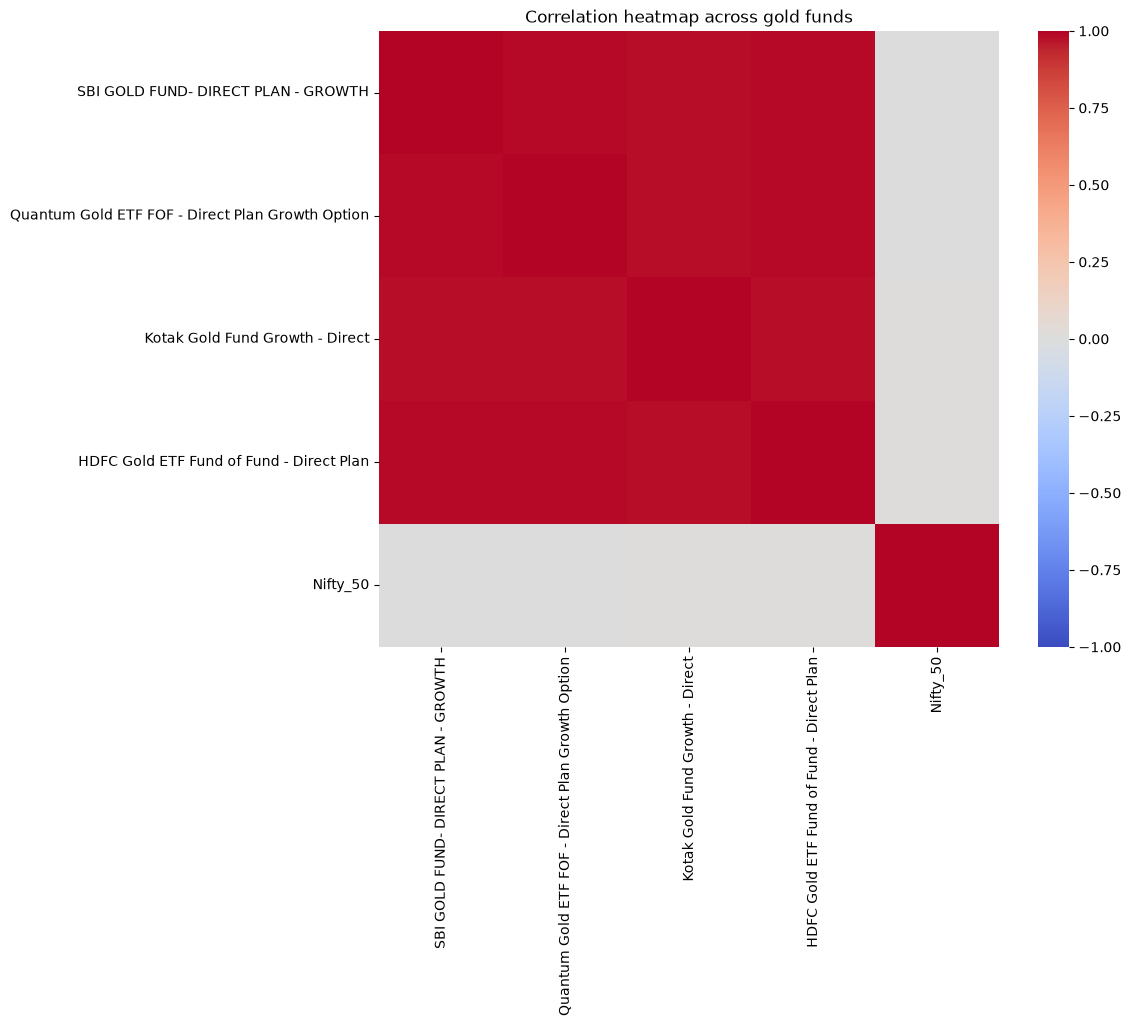

In [16]:
gold_with_benchmarks = pd.concat([gold_funds, nifty_50_returns['Nifty_50']], axis=1).dropna()
gold_corr_matrix = gold_with_benchmarks.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    gold_corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across gold funds")
plt.show()

In [17]:
silver_funds = returns_matrix[[code for code in fund_types['silver'].keys() if code in returns_matrix.columns]]
silver_funds = silver_funds.rename(columns=fund_types['silver'])
silver_funds

,ICICI Prudential Silver ETF FOF - Direct Plan - Growth,Nippon India Silver ETF FOF- Direct Plan-Growth Option
date,,
2022-02-18,0.023124,0.022406
2022-02-25,0.014891,0.013457
2022-03-04,0.041025,0.043783
2022-03-11,0.024895,0.029847
2022-03-18,-0.023988,-0.027695
...,...,...
2026-08-28,-0.009674,-0.010783
2026-09-04,-0.033468,-0.033188
2026-09-11,-0.026178,-0.027228


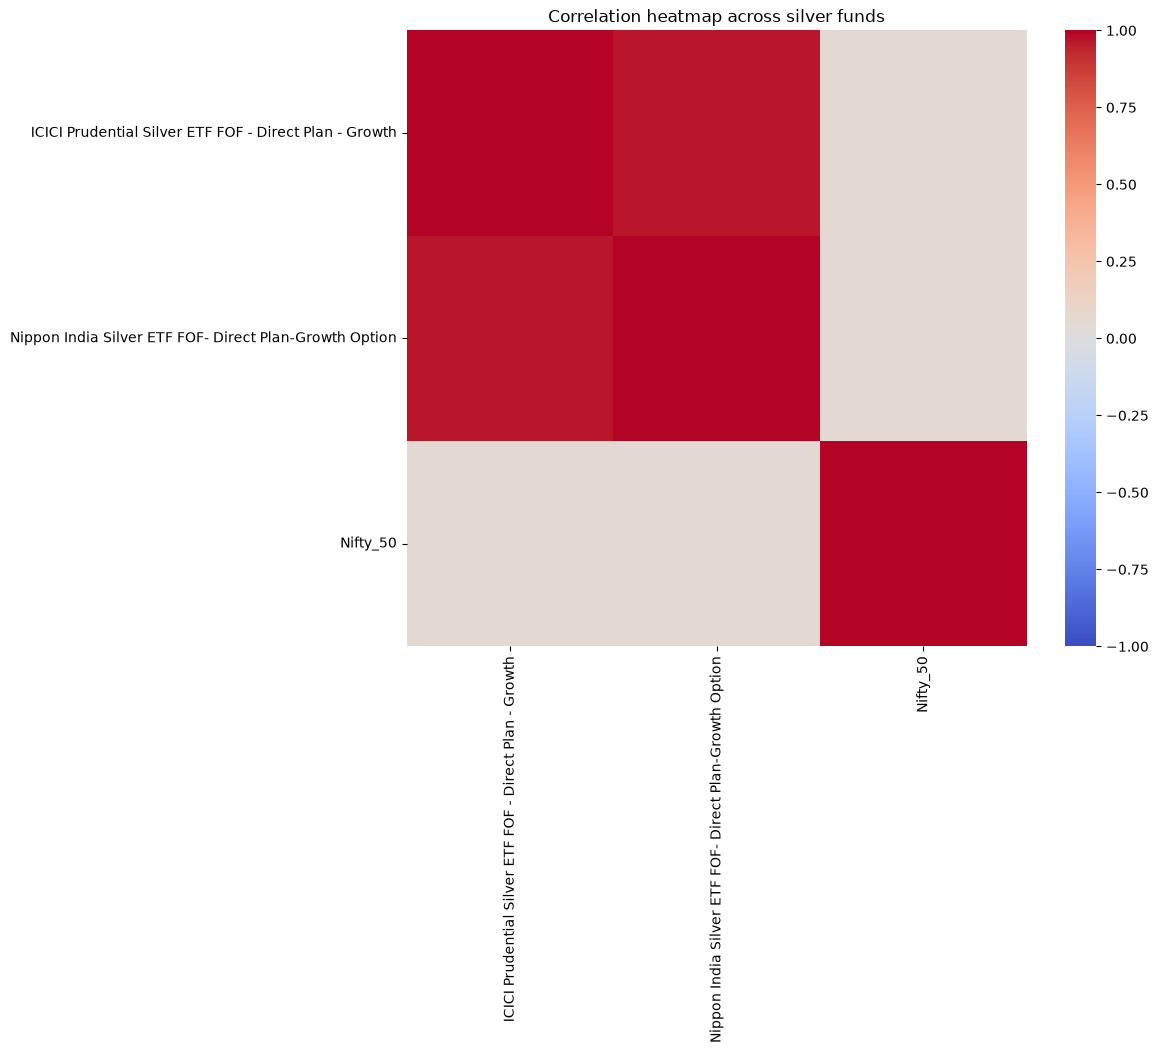

In [18]:
silver_with_benchmarks = pd.concat([silver_funds, nifty_50_returns['Nifty_50']], axis=1).dropna()
silver_corr_matrix = silver_with_benchmarks.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    silver_corr_matrix, 
    annot=False,      
    cmap="coolwarm",  # Good palette for positive/negative values
    vmin=-1, vmax=1,  # Force colorbar bounds to match correlation limits
    fmt=".2f"         
)

plt.title("Correlation heatmap across silver funds")
plt.show()

In [19]:
midcap_metrics_df = calculate_metrics_df(midcap_funds, nifty_50_returns['Nifty_50'])
midcap_metrics_df

,CAGR,Volatility,Alpha,Beta,Sharpe Ratio,Max Drawdown,Information Ratio
Invesco India Mid Cap Fund - Direct Plan - Growth Option,0.208056,0.165381,0.132719,1.079483,0.828026,-0.191454,1.432268
ICICI Prudential Mid Cap Fund - Direct Plan - Growth,0.186135,0.165095,0.114280,1.088325,0.717980,-0.202540,1.262240
Union Midcap Fund - Direct Plan - Growth Option,0.163967,0.155624,0.094206,0.998640,0.630431,-0.206476,1.046216
HDFC Mid Cap Fund - Growth Option - Direct Plan,0.197570,0.147800,0.121660,0.976482,0.848971,-0.163783,1.513825
Kotak Mid Cap Fund - Direct Plan - Growth,0.175728,0.149212,0.103436,0.966556,0.718539,-0.202660,1.218387
Mirae Asset Midcap Fund - Direct Plan - Growth,0.161503,0.155632,0.091993,1.026257,0.616875,-0.224148,1.084072
Nippon India Growth Mid Cap Fund - Direct Plan Growth Plan - Growth Option,0.192575,0.157143,0.118684,1.026483,0.780800,-0.194082,1.355258
Edelweiss Mid Cap Fund - Direct Plan - Growth Option,0.195827,0.158469,0.121572,1.039565,0.792814,-0.193951,1.389170


In [20]:
smallcap_metrics_df = calculate_metrics_df(smallcap_funds, nifty_50_returns['Nifty_50'])
smallcap_metrics_df

,CAGR,Volatility,Alpha,Beta,Sharpe Ratio,Max Drawdown,Information Ratio
Union Small Cap Fund - Direct Plan - Growth Option,0.185832,0.178471,0.116784,0.990694,0.676062,-0.247471,0.923065
BANK OF INDIA Small Cap Fund Direct Plan Growth,0.209670,0.181453,0.137168,1.008272,0.777668,-0.252393,1.068039
ITI Small Cap Fund - Direct Plan - Growth Option,0.226636,0.180467,0.150718,1.082413,0.858608,-0.228209,1.288096
DSP Small Cap Fund - Direct Plan - Growth,0.182706,0.170048,0.112846,0.929437,0.684980,-0.223791,0.917890
Invesco India Small Cap Fund - Direct Plan - Growth,0.212402,0.175453,0.138174,1.066325,0.811290,-0.221092,1.238941
PGIM India Small Cap Fund - Direct Plan- Growth Option,0.139520,0.159414,0.073824,0.933871,0.485999,-0.206742,0.689192
Sundaram Small Cap Fund Direct Plan - Growth,0.176970,0.163791,0.106706,0.995623,0.675241,-0.225229,1.025987
Aditya Birla Sun Life Small Cap Fund - Growth - Direct Plan,0.155400,0.169073,0.089002,1.004977,0.549651,-0.244883,0.803693
quant Small Cap Fund - Growth Option - Direct Plan,0.188061,0.189089,0.120265,1.091557,0.658592,-0.240743,0.935075


In [21]:
debt_metrics_df = calculate_metrics_df(debt_funds, nifty_50_returns['Nifty_50'])
debt_metrics_df

,CAGR,Volatility,Alpha,Beta,Sharpe Ratio,Max Drawdown,Information Ratio
Aditya Birla Sun Life Medium Term Fund - Growth - Direct Plan,0.133177,0.075498,0.061742,0.005045,0.818061,-0.008968,0.392790
DSP Credit Risk Fund - Direct Plan - Growth,0.142248,0.069093,0.069250,0.045977,1.004876,-0.017513,0.469872
BANK OF INDIA Short Term Income Fund-Direct Plan- Growth,0.114632,0.078078,0.044995,0.106783,0.581625,-0.007450,0.302673
HDFC Income Plus Arbitrage Active FOF - Growth Option - Direct Plan,0.108224,0.059923,0.037231,0.359678,0.644774,-0.080906,0.385268
Nippon India Credit Risk Fund - Direct Plan - Growth Plan,0.079664,0.010473,0.010622,0.031169,1.025835,-0.010185,0.055325
ICICI Prudential Medium Term Fund - Direct Plan - Growth,0.076333,0.013381,0.007499,0.047200,0.574247,-0.011529,0.031014
Nippon India Corporate Bond Fund - Direct Plan Growth Plan - Growth Option,0.069300,0.012915,0.000949,0.041992,0.086186,-0.008795,-0.022861
Axis Corporate Bond Fund - Direct Plan Growth,0.069607,0.012426,0.001232,0.041552,0.112219,-0.008401,-0.020560
Franklin India Corporate Debt Fund - Direct - GROWTH,0.069893,0.011458,0.001523,0.032796,0.144071,-0.007979,-0.018306


In [22]:
gold_metrics_df = calculate_metrics_df(gold_funds, nifty_50_returns['Nifty_50'])
gold_metrics_df

,CAGR,Volatility,Alpha,Beta,Sharpe Ratio,Max Drawdown,Information Ratio
SBI GOLD FUND- DIRECT PLAN - GROWTH,0.264417,0.153248,0.180754,0.006702,1.179655,-0.132220,0.890785
Quantum Gold ETF FOF - Direct Plan Growth Option,0.264449,0.153333,0.180789,0.002792,1.179136,-0.127010,0.889171
Kotak Gold Fund Growth - Direct,0.260556,0.154817,0.177898,0.012322,1.149396,-0.128615,0.873179
HDFC Gold ETF Fund of Fund - Direct Plan,0.262942,0.153288,0.179578,0.010150,1.171770,-0.130713,0.886049


In [23]:
silver_metrics_df = calculate_metrics_df(silver_funds, nifty_50_returns['Nifty_50'])
silver_metrics_df

,CAGR,Volatility,Alpha,Beta,Sharpe Ratio,Max Drawdown,Information Ratio
ICICI Prudential Silver ETF FOF - Direct Plan - Growth,0.306613,0.292377,0.244417,0.131187,0.837720,-0.303435,0.772274
Nippon India Silver ETF FOF- Direct Plan-Growth Option,0.305916,0.309404,0.250759,0.134666,0.812161,-0.354156,0.754366
